In [1]:
# Libraries import karein
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Data download karein (Example: Google - 'GOOGL')
data = yf.download('GOOGL', start='2020-01-01', end='2024-01-01')
print(data.head())

/tmp/ipykernel_1779/2656414120.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('GOOGL', start='2020-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open    Volume
Ticker          GOOGL      GOOGL      GOOGL      GOOGL     GOOGL
Date                                                            
2020-01-02  67.873039  67.873039  66.772637  66.867851  27278000
2020-01-03  67.517952  68.124443  66.813773  66.847498  23408000
2020-01-06  69.317589  69.342877  66.996275  67.027511  46768000
2020-01-07  69.183701  69.599764  69.007658  69.449010  34330000
2020-01-08  69.676117  70.013826  69.060705  69.169304  35314000


In [2]:
# 1. Sirf 'Close' column ko select karna kyunke humne price predict karni hai
# Hum .values use kar rahe hain taake numpy array mil jaye
df_close = data['Close'].values.reshape(-1, 1)

# 2. Feature Scaling (Min-Max Scaler)
# Ye data ko 0 aur 1 ki range mein le aayega
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_close)

# 3. Training aur Testing set mein divide karna
# 80% data training ke liye aur 20% testing ke liye
training_data_len = int(np.ceil(len(scaled_data) * 0.8))

train_data = scaled_data[0:int(training_data_len), :]

print(f"Total data points: {len(scaled_data)}")
print(f"Training data points: {len(train_data)}")

Total data points: 1006
Training data points: 805


In [3]:
# Training datasets create karna
x_train = []
y_train = []

# Sliding window banayen (60 days)
for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

# Numpy arrays mein convert karein
x_train, y_train = np.array(x_train), np.array(y_train)

# LSTM ke liye data ko 3D reshape karna [samples, time steps, features]
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

print(f"X_train shape: {x_train.shape}")

X_train shape: (745, 60, 1)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# 1. Model Structure design karna
model = Sequential()

# Pehli LSTM layer (return_sequences=True kyunke agay aik aur LSTM layer hai)
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2)) # 20% neurons ko random band karna taake model generalize kare

# Doosri LSTM layer
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Output layer (Sirf 1 price predict karni hai)
model.add(Dense(units=1))

# 2. Model Compile karna
model.compile(optimizer='adam', loss='mean_squared_error')

# 3. Model Training
# Batch size 32 rakhte hain aur 20 epochs tak train karte hain
history = model.fit(x_train, y_train, batch_size=32, epochs=20)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 0.0524
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0080
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.0059
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.0055
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0055
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0047
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0055
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0051
Epoch 9/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0042
Epoch 10/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 0.0046
Epoch 11/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - loss: 0.0052
Epoch 12/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.0045
Epoch 13/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0043
Epoch 14/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0053
Epoch 15/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 0.0044
Epoch 16/20
24/

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step


/tmp/ipykernel_1779/1911094177.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid.loc[:, 'Predictions'] = predictions


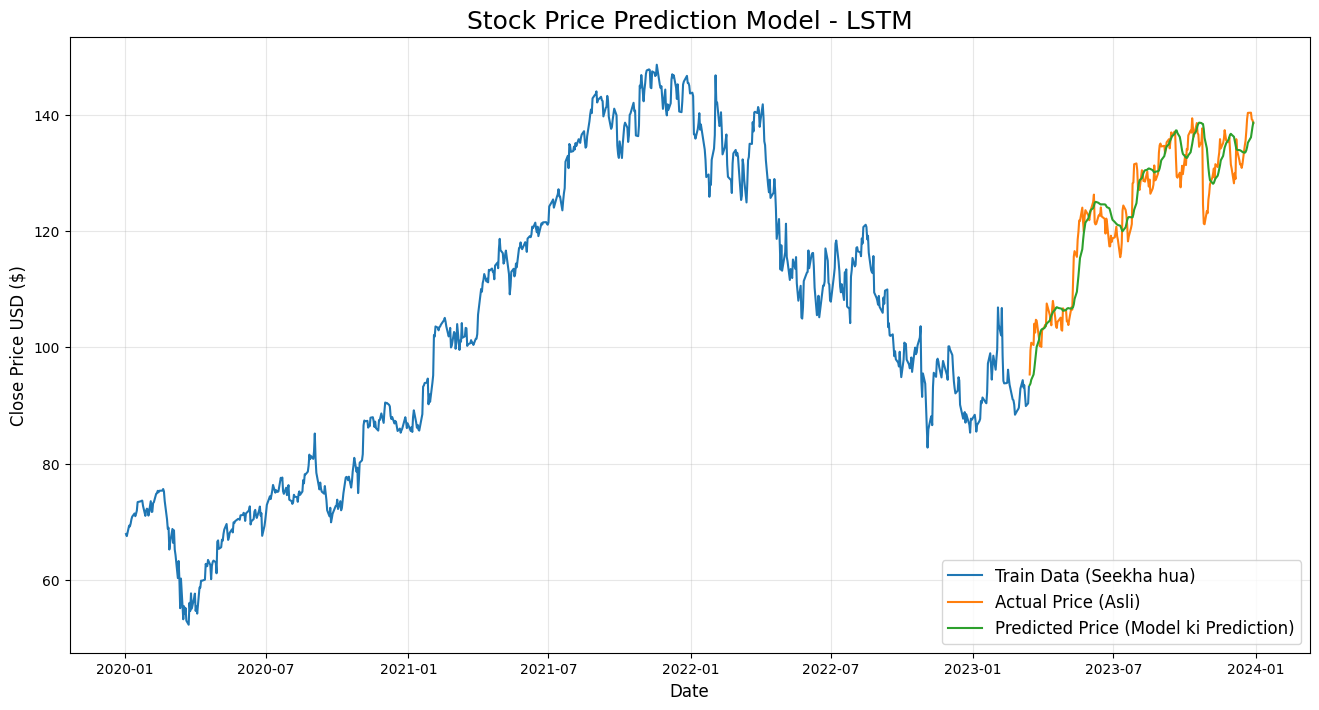

Model Error (RMSE): 4.015042623959362


In [5]:
# 1. Test data tayyar karna
test_data_window = scaled_data[training_data_len - 60: , :]
x_test = []
y_test = df_close[training_data_len:, :] # Actual prices

for i in range(60, len(test_data_window)):
    x_test.append(test_data_window[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# 2. Predictions lena
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions) # Wapis original price mein convert karna

# 3. Visualization ke liye data organize karna
train = data[:training_data_len]
valid = data[training_data_len:]
valid.loc[:, 'Predictions'] = predictions

# 4. Professional Graph (LinkedIn Ready)
plt.figure(figsize=(16,8))
plt.title('Stock Price Prediction Model - LSTM', fontsize=18)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price USD ($)', fontsize=12)
plt.plot(train['Close'], label='Train Data (Seekha hua)')
plt.plot(valid['Close'], label='Actual Price (Asli)')
plt.plot(valid['Predictions'], label='Predicted Price (Model ki Prediction)')
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Accuracy check karne ke liye RMSE (Root Mean Squared Error)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
print(f"Model Error (RMSE): {rmse}")

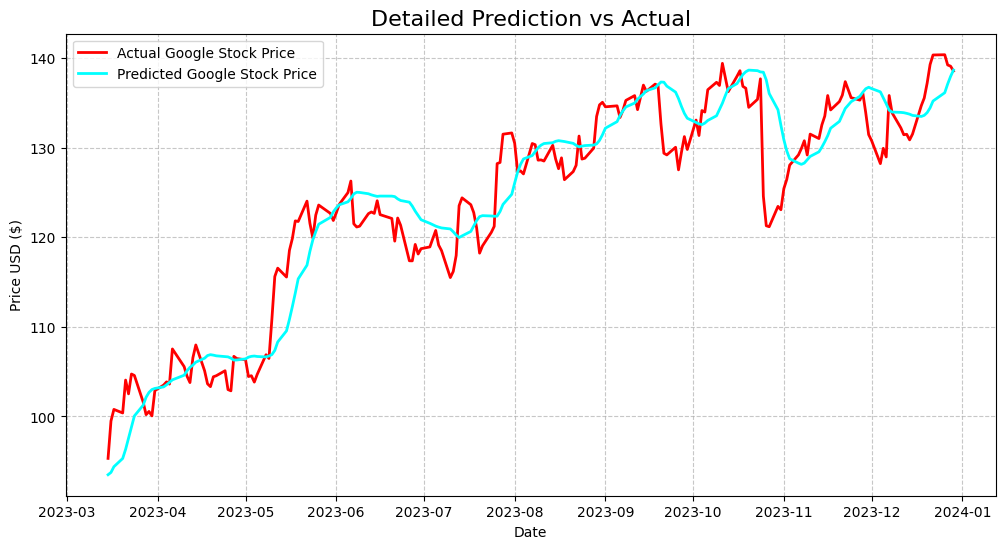

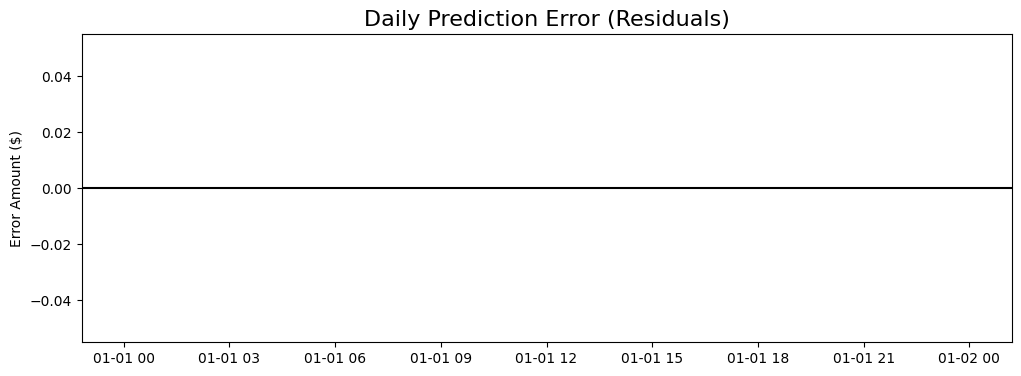

In [6]:
# Sirf Prediction area ko zoom karke dekhna
plt.figure(figsize=(12,6))
plt.plot(valid['Close'], color='red', label='Actual Google Stock Price', linewidth=2)
plt.plot(valid['Predictions'], color='cyan', label='Predicted Google Stock Price', linewidth=2)
plt.title('Detailed Prediction vs Actual', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price USD ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Ek aur cheez: Daily Error check karna
error = valid['Close'] - valid['Predictions']
plt.figure(figsize=(12,4))
plt.plot(error, color='purple')
plt.title('Daily Prediction Error (Residuals)', fontsize=16)
plt.axhline(y=0, color='black', linestyle='-')
plt.ylabel('Error Amount ($)')
plt.show()

In [7]:
import plotly.graph_objects as go

# Candlestick chart create karna
fig = go.Figure(data=[go.Candlestick(x=data.index,
                open=data['Open'],
                high=data['High'],
                low=data['Low'],
                close=data['Close'],
                name='Market Data'),
                # Prediction line add karna
                go.Scatter(x=valid.index, y=valid['Predictions'], line=dict(color='yellow', width=2), name='LSTM Prediction')])

fig.update_layout(title='Google Stock Price Interactive Analysis',
                  yaxis_title='Stock Price (USD $)',
                  xaxis_title='Date',
                  template='plotly_dark') # Dark theme for professional look

fig.show()